# Undertsanding standard deviation
This separate notebook dedicated to standard deviation might be unnecessary for the most of the geniuses out there but since I am dumb and I am facing difficulty understanding how , why and where standard deviations are used in real world and how it can make an impact, I have created this notebook that only tackles standard deviation. <br>
Here in this notebook you will see my inner thought process how I handle standard deviation from a noob prospective. <br>
NOTE : If you find that I did something wrong or may be the step I followed could have been handled better then please don't be shy to mention it in the comments below.

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv("/home/aditya/github/Deep-learning-prerequisite/pandas/dataset/nyc_weather.csv") # pc1
# df = pd.read_csv("/home/machine_learning/github/Deep-learning-prerequisite/pandas/dataset/nyc_weather.csv") # mac
df

,EST,Temperature,DewPoint,Humidity,Sea Level PressureIn,VisibilityMiles,WindSpeedMPH,PrecipitationIn,CloudCover,Events,WindDirDegrees
0,1/1/2016,38,23,52,30.03,10,8.0,0,5,NaN,281
1,1/2/2016,36,18,46,30.02,10,7.0,0,3,NaN,275
2,1/3/2016,40,21,47,29.86,10,8.0,0,1,NaN,277
3,1/4/2016,25,9,44,30.05,10,9.0,0,3,NaN,345
4,1/5/2016,20,-3,41,30.57,10,5.0,0,0,NaN,333
5,1/6/2016,33,4,35,30.50,10,4.0,0,0,NaN,259
6,1/7/2016,39,11,33,30.28,10,2.0,0,3,NaN,293
7,1/8/2016,39,29,64,30.20,10,4.0,0,8,NaN,79
8,1/9/2016,44,38,77,30.16,9,8.0,T,8,Rain,76
9,1/10/2016,50,46,71,29.59,4,NaN,1.8,7,Rain,109


## Before I start these are the things I found online. I have distilled it into points for me to understand better.
### Calculate standard deviation
- Standard Deviation (σ) is a statistical measure that tells you how spread out the values in a dataset are from the mean (average)
- If the values are close to the mean, the standard deviation is small.
- If the values are spread out, the standard deviation is large..

### Why standard deviation is important
- Detecting anomalies and outliers:
  - If a data point is several standard deviation away from the mean, it's likely and outlier.
  - It is used for Fraud detection, quality control, sensor anomalies.
- Comparing performance consistency:
  - Let's say I have to analyze the test score of two students over several exams:
  - Student A has more consistent performance.
  - Student B has higher variability.
  - Useful for: HR appraisals, academic evaluations, product quality
- Risk assesment in Finance:
  - Standar deviation is often used as a measure of risk in investment returns.
  - Higher standard deviation means more unpredictable returns and higher risks.
  - Useful for portfolio management, stock analysis.
- Understanding spread in distributions:
  - You can visualize it using histogram + standard ranges to understand how data clusters around the mean

### Here I will just calculate standard deviation normally

In [35]:
df["Temperature"].std()

7.639315400279415

### Ok so whats the mean ?

In [36]:
df["Temperature"].mean()

34.67741935483871

### According to the defination standard deviation should tell me if the data points are closer or further from the mean or the average of all the values in the temperature column of the dataframe.
- Ok so I calculated mean and I calculated standard deviation now what?
- I still don't understand these numbers
- What If i plot something may be then it will give me what it actually means using matplotlib.
- Using matplotlib here is the official link to their documentation if anyone of you want to take a look https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.hist.html

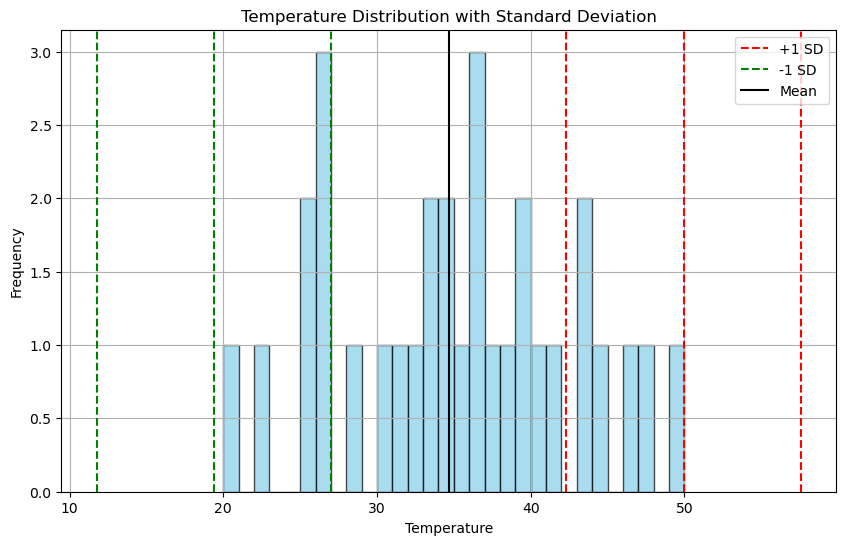

In [37]:
# Calculate mean and standard deviation
standard_deviation = df["Temperature"].std()
mean = df["Temperature"].mean()

# Plot histogram
plt.figure(figsize=(10,6))
plt.hist(df["Temperature"],bins=30,color="skyblue",edgecolor="black",alpha=0.7)

# Add lines for the mean and ±1, ±2, ±3 standard deviations
for i in range(1, 4):
    plt.axvline(mean + i * standard_deviation, color="red", linestyle="--", label=f"+{i} SD" if i == 1 else "")
    plt.axvline(mean - i * standard_deviation, color="green", linestyle="--", label=f"-{i} SD" if i == 1 else "")


plt.axvline(mean, color="black", linestyle="-", label="Mean")

plt.title("Temperature Distribution with Standard Deviation")
plt.xlabel("Temperature")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()

## Code explanation:
- plt.figure(figsize=(10,6)): Sets the plot size (width 10, height 6 inches).
- plt.hist(...): Creates a histogram of the Temperature column.
- ```python
     for i in range(1, 4):
        plt.axvline(mean + i * standard_deviation, color="red", linestyle="--", label=f"+{i} SD" if i == 1 else "")
        plt.axvline(mean - i * standard_deviation, color="green", linestyle="--", label=f"-{i} SD" if i == 1 else "")
  ```
  - What is the purpose of this code block?:
    - This code is drawing verticle lines on the histogram to visually show how far the data spreads from the mean in terms of standard deviations -- a common technique in statistical visualization.
    - This helps answer questions like:
      - Is the data normally distributed?
      - How much of the data falls within ±1, ±2, ±3 standard deviations from the mean?
    - plt.axvline(): What is it?
        | Parameter   | Meaning                                                     |
        | ----------- | ----------------------------------------------------------- |
        | `x`         | The x-coordinate (value) at which to draw the vertical line |
        | `color`     | Color of the line (e.g., `"red"`, `"green"`)                |
        | `linestyle` | Line style (e.g., `"--"` is dashed)                         |
        | `label`     | Text shown in the legend for the line                       |
    - This loop runs for i = 1, 2, and 3. Each i corresponds to:
      - +1 SD, +2 SD, +3 SD (standard deviations above the mean)
      - -1 SD, -2 SD, -3 SD (standard deviations below the mean)

- bins=30: Divides data into 30 intervals.
  - In my finding I found out that when changing the bin value the vertical blue bars gets either wider or thinner, also when I set the bin value to 10 or 5 I found that the number of vertical blue bars coinside with the number passed in the bin parameter.
  
### Ok so that's fine and good what what does it mean by "Divides data into 30 intervals"?
- In a histogram, bins determines how many groups (or intervals) the data range is divided into.
- When I write bins=30, I am asking Matplotlib to split my data into 30 equal-width intervals (or "buckets") or so I understood from the articel I read.
- Each bin represents a range of values
- The height of each bar represents how many data points fall into that range.
    
### What is the point? what does it mean to make bars thinner or wider?
  - Fewer bins = Wider bars = Less granularity
  - More bins = Narrow bars = More detailed view
  - ok so that means if I set
    - bins=5: I will see 5 wide bars.
    - bins=10: I will see 10 narrower bars.
    - bins=30: I will see 30 thin bars (more detailed spread).
    
### So why the specific number 30 for setting up the bin here ?
- So after searching the web like a madman all I found the information that I am sharing below
  - There is no universal best number of bins. It depends on:
    - How much detial I want to show
    - How large my dataset is
    - Whether I am tring to show smooth trends or just broad patterns
- Too fewer bins:
  - I might oversimplify the data and hide important patterns
- Too many bins
  - I might introduce noise, making the data look overly "spiky" and hard to interpret
  
### !! Why? why is this kolavery di? Why haven't someone created a formula to set the correct number in the bin? How do working professionals in datascience field know what number to set here and still manage to maintain the balance between too fewer bins and too many bins !!

## There must be a way to accurately set the bin for constructing a histogram that is not only accurate but also has minimum amount of noise
I refuse to accept that there isn't a way. <br>
So far what I have at my disposal is the information that the matplotlib/pandas 
- finds the min and max of my temperature column
- divides that range into X equally-sized intervals (bins)
- counts how many temperature values fall into each bin
- Plots the bar heights = number of values in each bin. 

In [38]:
df["Temperature"].count()

31

In [39]:
df["Temperature"].max()

50

In [40]:
df["Temperature"].min()

20

### 3 Hrs later I found this pdf online Sturges' Rules to find the bin value for the histogram
Here is the link to the pdf file I found : https://robjhyndman.com/papers/sturges.pdf

Long story short I can use this formula to calculate the bin 
k = 1 + log2 n.
Where k is the bin and n is the number of data points in my dataframe here in my case its 31

### Ok so lets create a function in python that calculates the bin automatically by getting the count of the data from the desired column from the dataFrame and apply the Sturges' Rule to find the optimum value for bin to create a histogram

In [45]:
import math
def calculate_bin_value_using_sturge(data_point_count):
    if data_point_count<=0:
        raise ValueError("Number of data points must be grater than zero")
    # math.ceil() ensures you round up to the nearest whole number, 
    # ensuring the number of bins is enough to cover the data distribution properly.
    return math.ceil(math.log2(data_point_count)+1)

In [46]:
calculate_bin_value_using_sturge(31)

6

#### Ok so far so good the function is returning the calculated bin just as expected. Now all I need to do is to make use of it in matplotlib

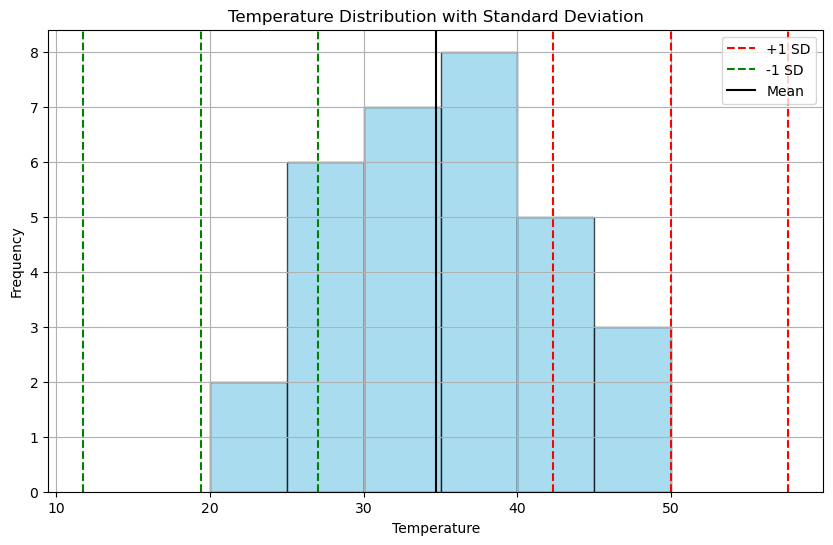

In [43]:
# Calculate mean and standard deviation
standard_deviation = df["Temperature"].std()
mean = df["Temperature"].mean()
data_count = df["Temperature"].count()

# Plot histogram
plt.figure(figsize=(10,6))
plt.hist(df["Temperature"],bins=calculate_bin_value_using_sturge(data_count),color="skyblue",edgecolor="black",alpha=0.7)

# Add lines for the mean and ±1, ±2, ±3 standard deviations
for i in range(1, 4):
    plt.axvline(mean + i * standard_deviation, color="red", linestyle="--", label=f"+{i} SD" if i == 1 else "")
    plt.axvline(mean - i * standard_deviation, color="green", linestyle="--", label=f"-{i} SD" if i == 1 else "")


plt.axvline(mean, color="black", linestyle="-", label="Mean")

plt.title("Temperature Distribution with Standard Deviation")
plt.xlabel("Temperature")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()

### When reading the pdf file for sturges' rule I found out this line to be very intresting
```
This is Sturges’ rule. If the data are not normal, additional classes may be required
```
### But what does this line mean ?
- If my dataset is not normally distributed (e.g., it's skewed, has outliers, or has multiple peaks), then the number of bins suggested by Sturges’ rule might not be enough.
- I may need to increase the number of bins to better capture the actual shape and spread of my data.
### What is normally distributed data:
- 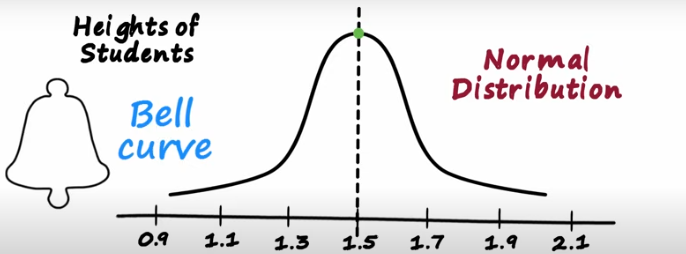
### Ok so that is postitively skewed distribution?
- 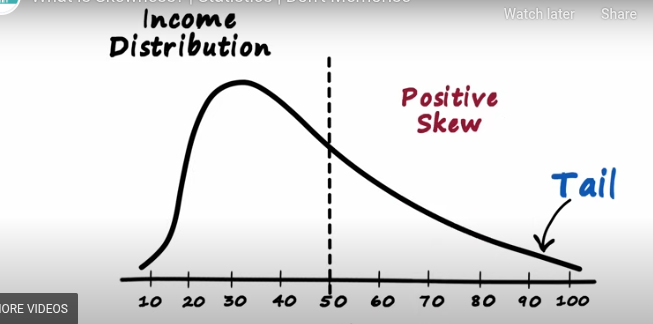
### Then the negatively skewed distribution must look like this:
- 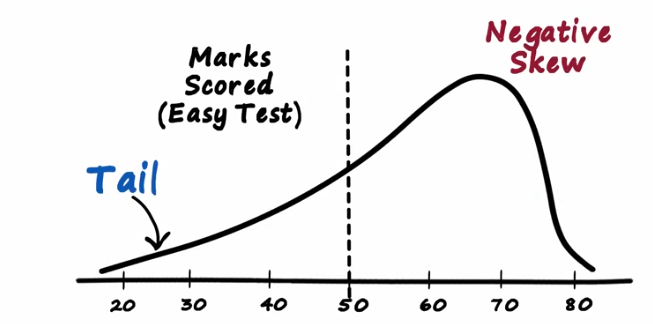
### I refered to this article to gain clarity on what is skewness 
- https://builtin.com/data-science/skewed-data

### Observation: 
- After comparing the negatively and positively skewed distribution and normal distribution. I am leaning towards that my dataset is negatively skewed
- Let me see if there is a method to confirm my suspicion.
- This article helped me understand what type of skewness accours and when https://www.geeksforgeeks.org/maths/skewness-formula/

### After reading the article things I focused on 
- Condition for positive skewness = Mean > Median >Mode
- Condition for negative skewness is Mode > Median > Mean
- Condition for zero skewness or normal distribution is Mean = Mode = Median

### Is there a way to calculate Mode and Median in Pandas let me check
- Ok so I found out that it is by using .median() function
  - I refered to this doc https://pandas.pydata.org/docs/getting_started/intro_tutorials/06_calculate_statistics.html

### What is midean exactly?
- Median refers to a metric used in statistics. It’s the middle number in a sorted ascending or descending list of numbers and can be more descriptive of the dataset than the average. It’s the point above and below which 50% of the observed data falls, so it represents the midpoint of the data.
  - If there is an odd amount of numbers, the median value is the number that is in the middle, with the same amount of numbers below and above.
  - If there is an even amount of numbers in the list, the middle pair must be determined, added together, and divided by two to find the median value.
- Links to the docs : https://www.investopedia.com/terms/m/median.asp

### What is mode?
- In statistics, the mode is the value that appears most frequently in a set of data. It's one of the measures of central tendency, alongside the mean and median. For example, in the set {2, 3, 3, 4, 4, 4, 4, 5, 5, 5, 6, 6, 7}, the mode is 4, as it appears four times, more than any other number.

In [44]:
# Lets calculate mean first
mean_temperature = df["Temperature"].mean()

# Calculating median
median_temperature = df["Temperature"].median()

# Calculating mode 
mode_temperature = df["Temperature"].mode()

if mean_temperature < median_temperature and median_temperature < mode_temperature.min():
    print("Distribution is Left-Skewed")
elif mean_temperature > median_temperature and median_temperature > mode_temperature.min():
    print("Distribution is Right-Skewed")
else:
    print("Distribution is Approximately Normal")

Distribution is Approximately Normal


### Oh brother I am an idiot a big idiot I din't even realise that pandas has an inbuilt function to calculate skewness of the histogram


####  DataFrame.skew(axis=0, skipna=True, numeric_only=False)
This method calculates the skewness of the distribution of each column in a DataFrame. <br>
| Parameter      | Description                                                                |
| -------------- | -------------------------------------------------------------------------- |
| `axis`         | `0` (default) → column-wise calculation; `1` → row-wise                    |
| `skipna`       | `True` (default) → skip `NaN` values                                       |
| `numeric_only` | `False` (default) → include non-numeric columns unless specified otherwise |

Here is the link to the related documentation : https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.skew.html

In [48]:
skewness_temperature = df["Temperature"].skew(axis=0,skipna=True,numeric_only=True)
skewness_temperature

0.0042630201718569065

#### So that this number returned by skewness_temperature means
This number represents the skewness of your Temperature column — a measure of how symmetric your data is around the mean.
- A skewness of 0 means perfect symmetry (like a normal distribution).
- A positive value indicates a right-skew (tail on the right side).
- A negative value indicates a left-skew (tail on the left side).

Result: 0.00426...
This is:

    Very close to zero

    Slightly positive, but the amount is negligible

Hence according to this information, slight skewness can be safley ignored when calculating bins for histogram using sturges' rule

## Ok so now I am curious what would happen if I have data that is positively skewed.
According to this pdf https://robjhyndman.com/papers/sturges.pdf <br>
We have to use this rule Freedman and Diaconis’s (1981) rule for the class width. <br>
The formula of Freedman and Diaconis’s (1981) rule looks something like this: <br>
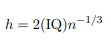

#### Since I don't have the positively skewed data in my dataFrame I have to generate positively skewed data using exponential distribution

In [50]:
import numpy as np
np.random.seed(42)
data = np.random.exponential(scale=2,size=100)
df = pd.DataFrame(data,columns=["SkewedDataPositive"])
df

,SkewedDataPositive
0,0.938536
1,6.020243
2,2.633491
3,1.825885
4,0.339250
...,...
95,1.361629
96,1.479358
97,1.115628
98,0.051496


In [51]:
# Calculate skewness
skewness = df["SkewedDataPositive"].skew()
skewness

1.5227244691308066

#### Since the number returned is positive we can safely say that the data points is positively skewed

#### First lets see what bin value is returned by sturges' rule when the data points are positively skewed

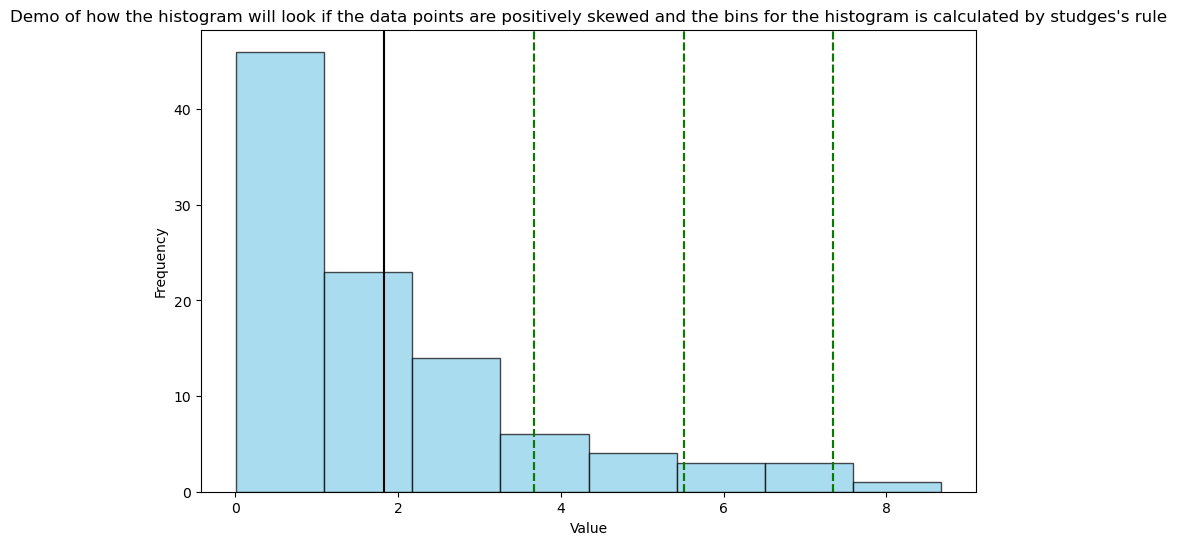

In [57]:
standard_deviation = df["SkewedDataPositive"].std()
mean = df["SkewedDataPositive"].mean()
data_count = df["SkewedDataPositive"].count()

# plot histogram
plt.figure(figsize=(10,6))
plt.hist(df["SkewedDataPositive"], bins=calculate_bin_value_using_sturge(data_count),color="skyblue",edgecolor="black",alpha=0.7)

# Add lines for the mean and ±1, ±2, ±3 standard deviations
for i in range(1,4):
    plt.axvline(mean + i * standard_deviation, color="red", linestyle="--", label=f"+{i} SD" if i == 1 else "")
    plt.axvline(mean + i * standard_deviation, color="green", linestyle="--", label=f"i{i} SD" if i == 1 else "")

plt.axvline(mean,color="black", linestyle="-",label="Mean")

plt.title("Demo of how the histogram will look if the data points are positively skewed and the bins for the histogram is calculated by studges's rule")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()

#### Now let's see how the histogram will look if I use Freedman and Diaconis’s (1981) rule

In [ ]:
# This function calculates the bin value using Freedman and Diaconis’s (1981) rule when the data is positively skewed
def Freedman_and_Diaconis_rule():
    